# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [5]:
# Import the library
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

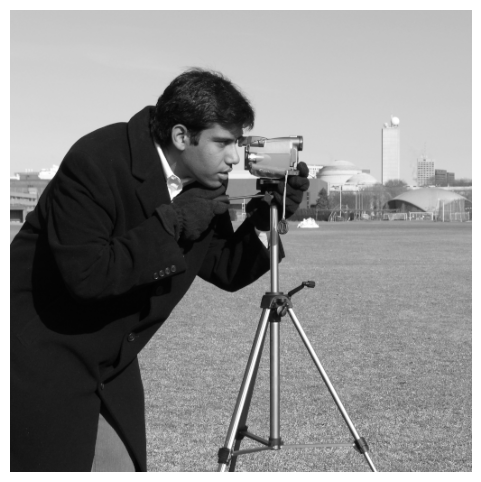

In [9]:
# ── Load image ────────────────────────────────────
img = Image.fromarray(data.camera())

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [44]:
# Get the size of the image
width, height = img.size
print("Original size:", width, height)

# scaling factors
sx = 2
sy = 2

Original size: 512 512


In [45]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize(
    (width * sx, height * sy),
    Image.Resampling.LANCZOS
)


Original size: (512, 512)
Scaled size: (1024, 1024)


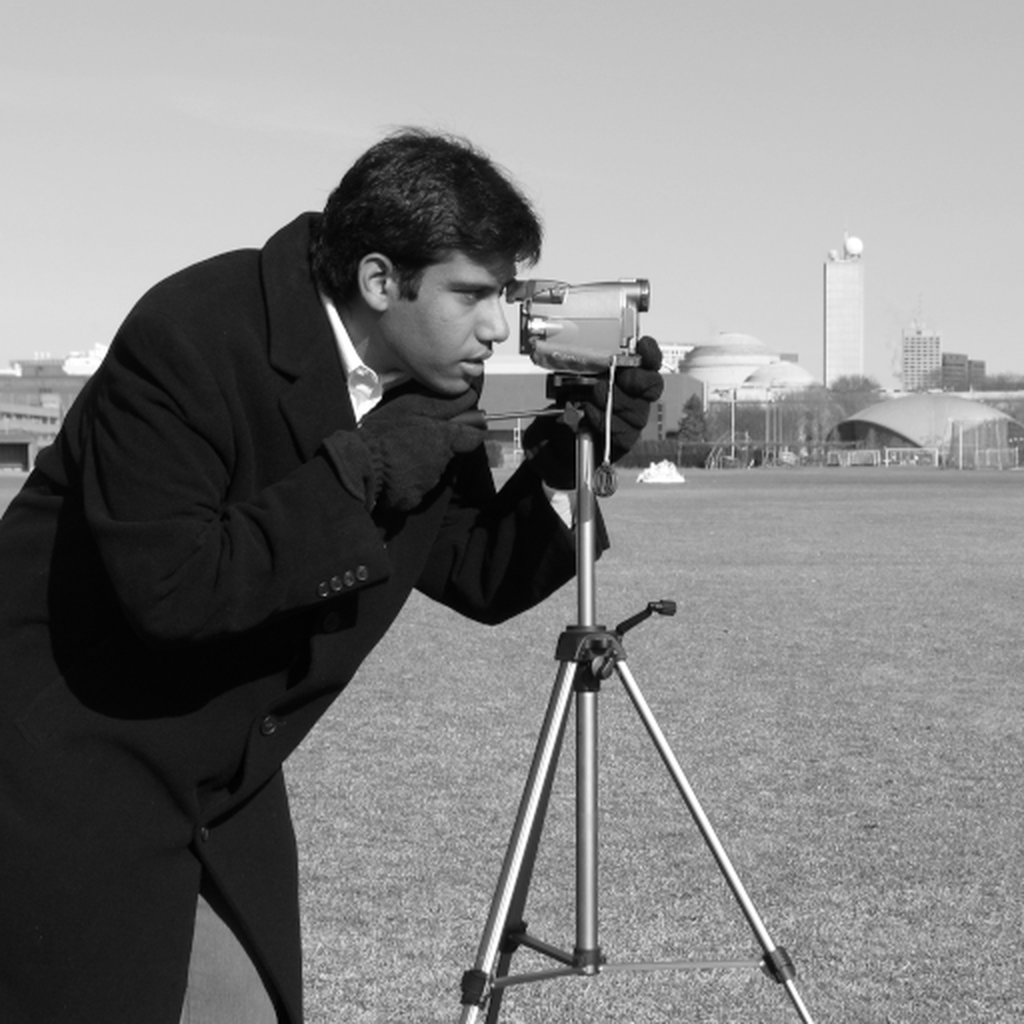

In [46]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

scaled_img

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [29]:
width, height = img.size
cx = 2
cy = 1

In [30]:
non_uniform_img = img.resize(
    (width * cx, height * cy),
    Image.Resampling.LANCZOS
)

Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


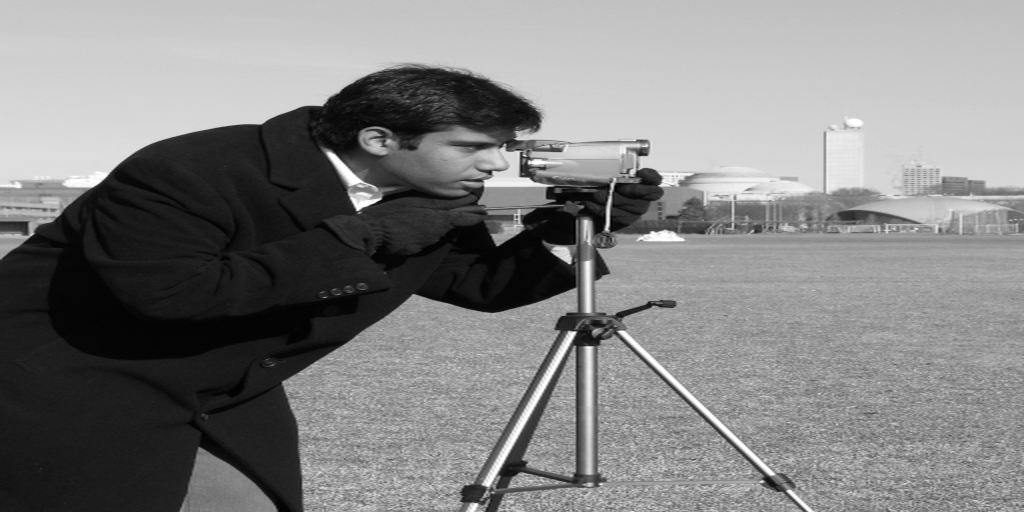

In [31]:
non_uniform_img.save("task1_2_nonuniform.jpg")

print("Original size:", img.size)
print("Non-uniform scaled size:", non_uniform_img.size)

non_uniform_img

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


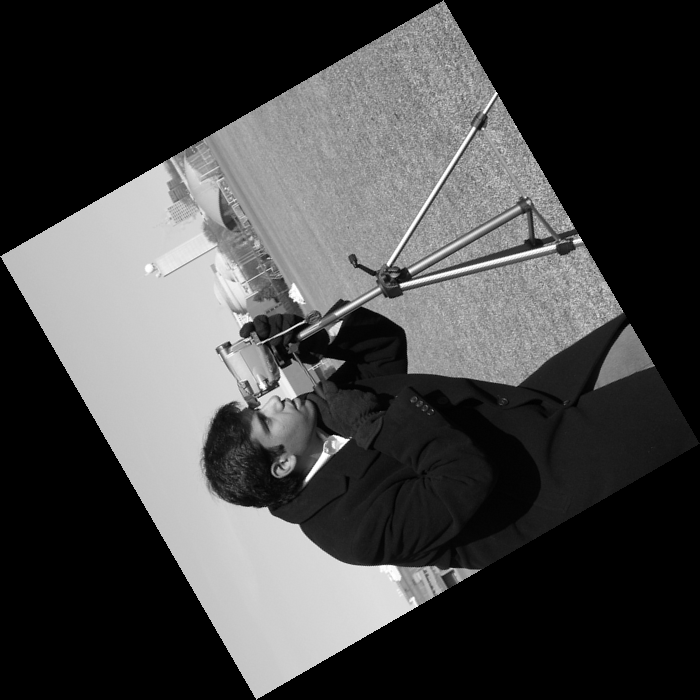

In [34]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(
    120,
    resample=Image.Resampling.BICUBIC,
    expand=True
)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

rotated_img

### 3. Shear

In [35]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

print("Original size:", img.size)

Original size: (512, 512)


In [36]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5

# Increase width so the sheared image is not cut off
new_width = int(width + abs(shx) * height)
new_height = height

Sheared size: (665, 665)


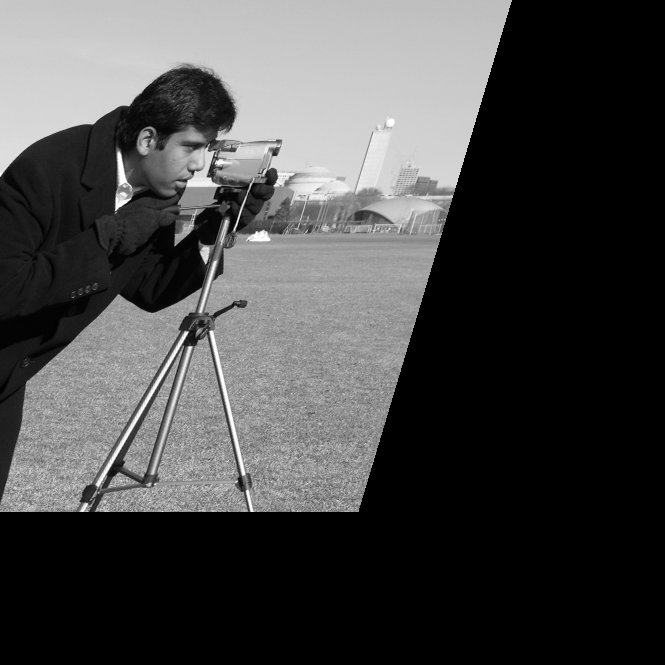

In [61]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, shx, 0,
     0,  1,   0),
    resample=Image.Resampling.BICUBIC
)

print("Sheared size:", sheared_img.size)

sheared_img

In [38]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

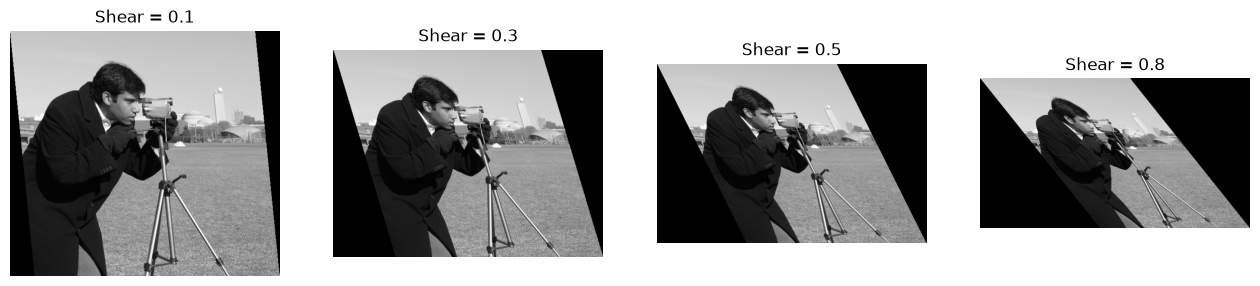

In [72]:
# 1. Compare different shear factors

factors = [0.1, 0.3, 0.5, 0.8]

plt.figure(figsize=(16, 4))

for i, shx in enumerate(factors):
    new_width = int(width + shx * height)

    result = img.transform(
        (new_width, height),
        Image.Transform.AFFINE,
        (1, -shx, 0,
         0, 1, 0),
        resample=Image.Resampling.BICUBIC
    )

    plt.subplot(1, 4, i + 1)
    plt.imshow(result, cmap="gray")
    plt.title(f"Shear = {shx}")
    plt.axis("off")

plt.show()

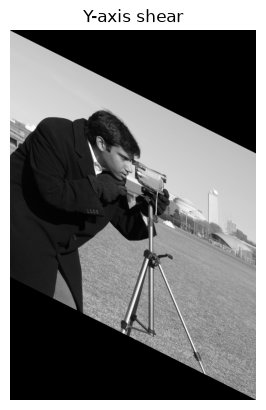

In [73]:
# 2. Y-axis shear

shy = 0.5

new_height = int(height + shy * width)

y_shear = img.transform(
    (width, new_height),
    Image.Transform.AFFINE,
    (1, 0, 0,
     -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

plt.imshow(y_shear, cmap="gray")
plt.title("Y-axis shear")
plt.axis("off")
plt.show()

Original size: (512, 512)
New canvas size: (921, 512)


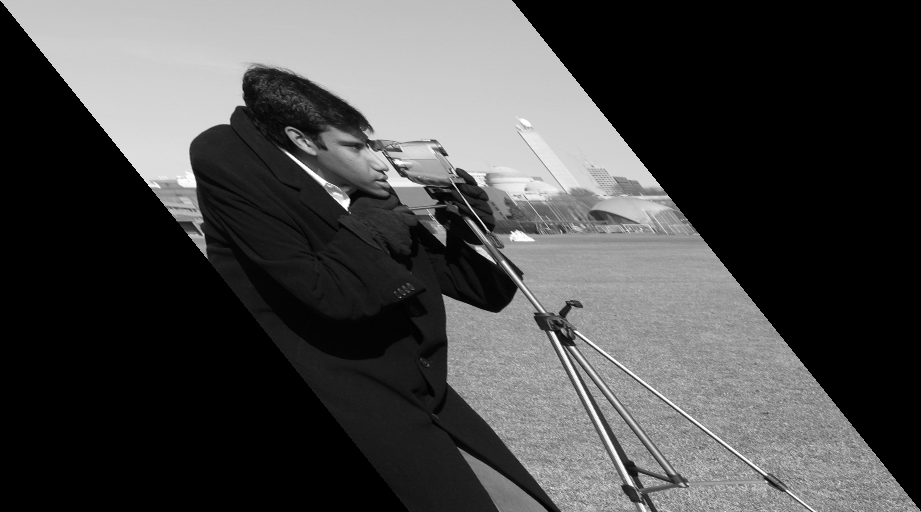

In [74]:
# 3. Update canvas size to match the new factor

shx = 0.8

new_width = int(width + shx * height)
new_height = height

canvas_shear = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0,
     0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print("Original size:", img.size)
print("New canvas size:", canvas_shear.size)

canvas_shear

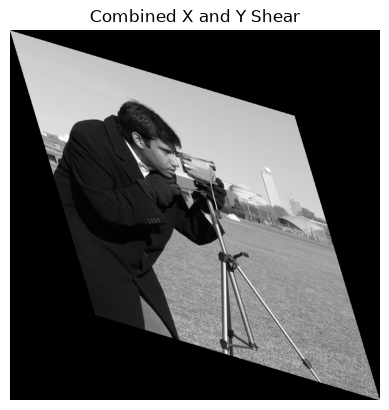

In [75]:
shx = 0.3
shy = 0.3

new_width = int(width + shx * height)
new_height = int(height + shy * width)

# PIL uses the inverse affine matrix
det = 1 - (shx * shy)

combined_shear = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (
        1 / det, -shx / det, 0,
        -shy / det, 1 / det, 0
    ),
    resample=Image.Resampling.BICUBIC
)

plt.imshow(combined_shear, cmap="gray")
plt.title("Combined X and Y Shear")
plt.axis("off")
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

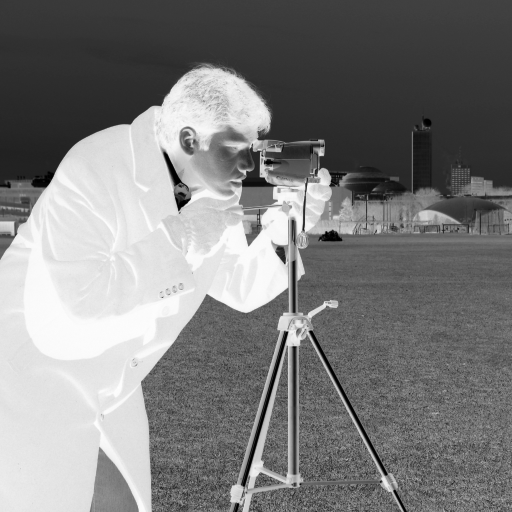

In [48]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
import numpy as np

arr = np.array(img)

negative_arr = 255 - arr
negative_img = Image.fromarray(negative_arr.astype(np.uint8))

negative_img.save("task2_1_negative_numpy.jpg")

negative_img



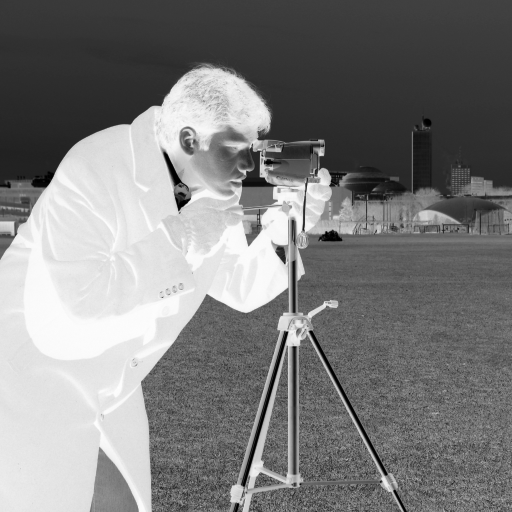

In [49]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

negative_pil = ImageOps.invert(img)

negative_pil.save("task2_1_negative_pil.jpg")

negative_pil

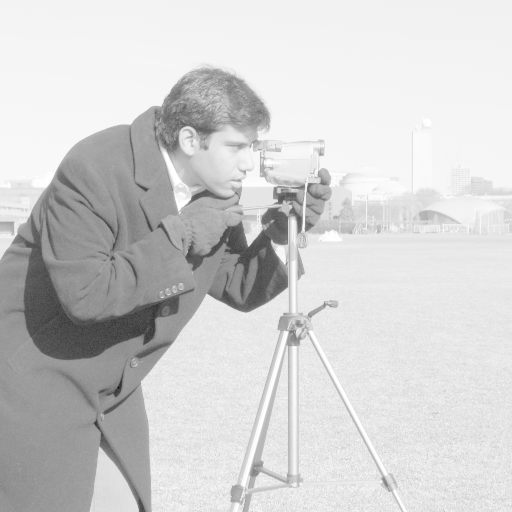

In [51]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
arr = np.array(img).astype(np.float32)

# s = c * log(1 + r)
c = 255 / np.log1p(255)


# Apply the log transformation to each pixel
log_transformed_arr = c * np.log1p(arr)
log_transformed_arr = np.clip(log_transformed_arr, 0, 255).astype(np.uint8)

log_img = Image.fromarray(log_transformed_arr)

log_img.save("task2_2_log.jpg")

log_img


In [ ]:

# ── 3. Power-law / Gamma correction ───────────────


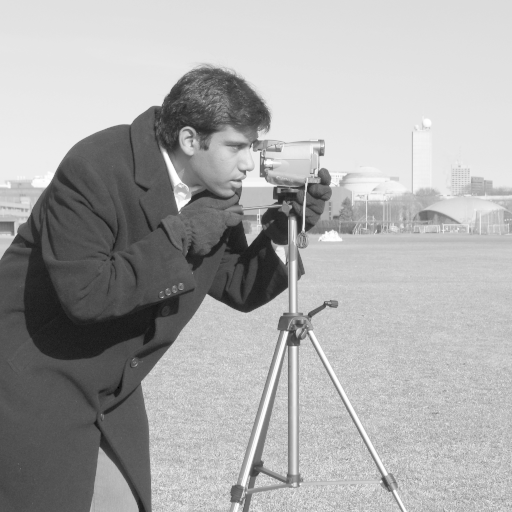

In [55]:
arr = np.array(img).astype(np.float32) / 255.0

gamma = 0.5

gamma_arr = 255 * (arr ** gamma)
gamma_arr = np.clip(gamma_arr, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_arr)

gamma_img.save("task2_3_gamma.jpg")

gamma_img